# `02-llm.ipynb`
- 기존 기계적인 워크플로우 -> LLM 삽입


- START -> LLM 분석 통해 State 변경 노드 -> 라우터가 긍정/부정/공격 -> [긍정] 칭찬노드 / [부정] 위로 노드 / [공격] 경고 노드  -> 문장 완성 노드 -> END
- state는 사용자 입력, 감정 상태, 핵심 메세지 (칭찬, 위로, 경고), 최종 답변
- llm 분석은 감정상태 채우기
- 칭찬, 위로, 경고 노드에서는 핵심 메세지 채우기
- 문장 완성 노드에서는 최종 답변 채우기


```mermaid
flowchart TD
    A[aaa] --> |good| B[bbb]
    B --> C[ccc]
```

1. warning_count를 어떻게 관리? -> state `warning_count`를 추가
2. `aggresive_node`에 도달하면, 무조건 경고 1회 추가
3. `aggresive_node` 이후 경고가 3회를 넘었다면 'block_user node` node로 이동해야함.
4. `block_user`는 단순히 `차단됨`이란 글자만 추가


In [22]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
# State 정의

from typing import TypedDict,Literal, NotRequired

class TeacherState(TypedDict):
    user_input: str   # 사용자 입력
    sentiment: NotRequired[Literal['positive', 'negative', 'aggresive']]   # 감정 분석
    core_msg: NotRequired[str] # 핵심 메세지
    response: NotRequired[str]     # 최종 답변



# {'user_input':  , }

In [24]:
# LLM 초기화 
from langchain.chat_models import init_chat_model

llm = init_chat_model('gpt-4-mini')


# 감정 분석 Node
def analyze_sentiment(state: TeacherState):
    prompt=f'''
    아래 문장의 감정을 분류.
    아래 3가지 단어 중 1가지 단어로 판단
    positive
    negative
    aggresive
    문장 : {state['user_input']}
    '''
    result = llm.invoke(prompt)
    return {'sentiment':result.content} # 바뀐 부분만 return


In [25]:
# 나머지 노드

import random

def positive_node(state: TeacherState):
    msgs = ['최고', '멋져', '훌륭']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}

def negative_node(state: TeacherState):
    msgs = ['힘내', '위로', '괜찮아']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}

def aggresive_node(state: TeacherState):
    return {'core_msg': '공격적인 표현은 삼가해주세요'}

In [26]:
# 완성 Node

def make_final_message(state: TeacherState):
    prompt = f''' 
    다음 사용자 입력에 맞는 답변을 생성해.
    핵심 키워드/메시지를 참조해야해.

    사용자 입력: {state['user_input']}
    핵심 키워드: {state['core_msg']}
    '''
    result = llm.invoke(prompt)
    return {'response': result.content}

In [ ]:
# 감정 분석 노드 라우터 
def router(state: TeacherState):
    return state['sentiment'] 

    

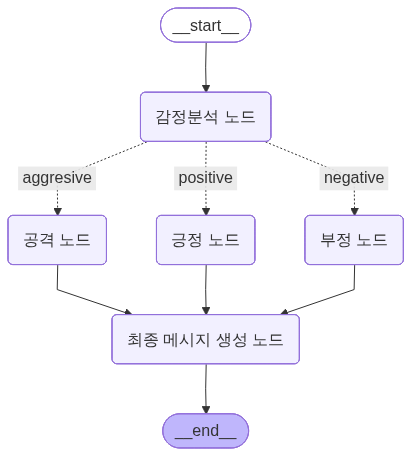

In [28]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(TeacherState)

# 노드 등록
graph.add_node('감정분석 노드',analyze_sentiment)
graph.add_node('긍정 노드', positive_node)
graph.add_node('부정 노드', negative_node)
graph.add_node('공격 노드', aggresive_node)
graph.add_node('최종 메시지 생성 노드',make_final_message)

# 엣지 등록
graph.add_edge(START,'감정분석 노드')
graph.add_conditional_edges('감정분석 노드', router, {'positive': '긍정 노드','negative': '부정 노드','aggresive': '공격 노드'})
graph.add_edge('긍정 노드', '최종 메시지 생성 노드')
graph.add_edge('부정 노드', '최종 메시지 생성 노드')
graph.add_edge('공격 노드', '최종 메시지 생성 노드')
graph.add_edge('최종 메시지 생성 노드',END)
app = graph.compile()
app

In [29]:
# LLM 초기화 
from langchain.chat_models import init_chat_model

llm = init_chat_model('gpt-4.1-mini')

prompt=f'''
    아래 문장의 감정을 분류.
    아래 3가지 단어 중 1가지 단어로 판단
    positive
    negative
    aggresive
    문장 : 나 너무 우울해
'''

llm.invoke(prompt)

AIMessage(content='negative', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1, 'prompt_tokens': 54, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_cde3adbea5', 'id': 'chatcmpl-DFZrkMgvibhhB4mRrxAWxYbC3VusH', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cb780-3c28-7aa2-8c26-16946c926970-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 54, 'output_tokens': 1, 'total_tokens': 55, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [30]:
app.invoke({'user_input':'슬퍼'})

{'user_input': '슬퍼',
 'sentiment': 'negative',
 'core_msg': '위로',
 'response': '슬플 때는 누구나 힘들죠. 무슨 일이 있었는지 이야기해도 괜찮아요. 혼자가 아니니까요, 함께 이겨낼 수 있을 거예요. 조금씩 마음이 편안해지길 진심으로 바랍니다.'}

In [ ]:
# app.invoke({'user_input':'배불러'})  
# -> 에러뜸 Why? positive | negative | aggresive 중 하나로만 나와야 하는데 '감정: negative' 이렇게 '감정: '이 부분까지 나옴

In [ ]:
app.invoke({'user_input':'짜증나'})



{'user_input': '짜증나',
 'sentiment': 'negative',
 'core_msg': '괜찮아',
 'response': '괜찮아, 누구나 가끔은 짜증날 수 있어. 천천히 숨 쉬고 조금 쉬어보는 건 어때?'}